In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

Set variables

In [21]:
sequence_length = 4 # max word length in the sentence
batch_size = 1 # for parallel processing
input_dim = 512 # dimension of every word that goes into the attention unit
d_model = 512 # output dimension of the output of attention unit for every word
X = torch.randn((batch_size, sequence_length, input_dim)) # randomly sampled input
# Note that X is the not the input of the overall transformer. 
# Instead its the input just before getting into the multi-head-attention phase.

In [22]:
X.shape

torch.Size([1, 4, 512])

Compute Q, K, V in a single concatenated vector

In [23]:
qkv_layer = nn.Linear(input_dim, 3 * d_model)

In [24]:
qkv = qkv_layer(X)

In [25]:
qkv.shape # 1 batch, 4 words and each word vector in size 1536

torch.Size([1, 4, 1536])

Text(0.5, 1.0, 'qkv distribution')

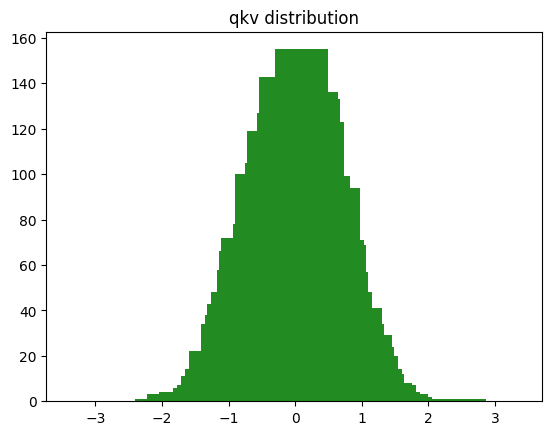

In [26]:
y_val = torch.histc(qkv, bins = 200, min = -3, max = 3)
x_val = np.arange(-1, 1, 0.01) * 3
plt.bar(x_val, y_val, align = 'center', color = ['forestgreen'])
plt.title('qkv distribution')

In [27]:
num_heads = 8
head_dim = d_model // num_heads
# rehshaping the last dimension to a product of the number of heads.
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim) # 3 because it containes Q, K and V concatenated

In [28]:
qkv.shape

torch.Size([1, 4, 8, 192])

In [30]:
qkv = qkv.permute(0, 2, 1, 3) # [batch_size, num_heads, sequence_length, 3 * head_dim] 
qkv.shape

torch.Size([1, 8, 4, 192])

Break down the projected matrices

In [32]:
q, k, v = qkv.chunk(3, dim=-1) # Breaking down by its last dimension
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

Self Attention for multiple heads

In [35]:
dk = q.size()[-1] # size of vectors 
scaled = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(dk) # transposing the k-tensor along seuqnce length and head_dim
scaled.shape

torch.Size([1, 8, 4, 4])

In [36]:
k.T.shape

torch.Size([64, 4, 8, 1])

In [ ]:
mask = torch.full(scaled.size(), float('-inf'))
mask = torch.triu(mask, diagonal=1) # upper triangular function
mask[0][1] # mask for input to a single head

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [38]:
(scaled + mask)[0][0]

tensor([[ 0.2524,    -inf,    -inf,    -inf],
        [ 0.3199, -0.4878,    -inf,    -inf],
        [-0.0139,  0.5599, -0.6946,    -inf],
        [ 0.0130,  0.2818,  0.0206,  0.1317]], grad_fn=<SelectBackward0>)

In [44]:
attention = F.softmax(scaled + mask, dim=-1) # application to last dimns make it row-wise

In [43]:
attention.shape
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.6916, 0.3084, 0.0000, 0.0000],
        [0.3048, 0.5409, 0.1543, 0.0000],
        [0.2251, 0.2946, 0.2268, 0.2535]], grad_fn=<SelectBackward0>)

In [45]:
values = torch.matmul(attention, v)
values.shape

torch.Size([1, 8, 4, 64])